# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Mohammad Dzikri Raihan
- Email: dzikrijokowi@gmail.com
- Id Dicoding: owiaja

## Persiapan

### Menyiapkan library yang dibutuhkan

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Menyiapkan data yang akan diguankan

## Data Understanding

In [8]:
# Baca dataset
data = pd.read_csv('dataset/employee_data.csv')

print("Data Employee:")
display(data.head())

# Cek statistik deskriptif awal (cek anomali/outlier)
print("\nStatistik Deskriptif data:")
display(data.describe())

Data Employee:


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2



Statistik Deskriptif data:


,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Data Preparation / Preprocessing

In [9]:
# Cek apakah ada data yang kosong (missing values)
print("\nJumlah Missing Values data:")
print(data.isna().sum())

# Cek apakah ada data yang duplikat
print("\nJumlah Data Duplikat data:", data.duplicated().sum())



Jumlah Missing Values data:
EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBal

In [25]:
# handle missing values di Data
data.dropna(subset=['Attrition'], inplace=True)

# cek hasil akhir setelah pembersihan
print("Jumlah Missing Values setelah Cleaning:")
print(data.isna().sum())
print("\nUkuran data sekarang:", data.shape)

Jumlah Missing Values setelah Cleaning:
EmployeeId                  0
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0


### Exploratory Data Analysis (EDA)


### Menjawab Permasalahan Bisnis 1: Identifikasi Faktor Utama
Kita akan mengeksplorasi hubungan *Attrition* dengan faktor kompensasi finansial (Monthly Income) dan kepuasan kerja (Job Satisfaction & Environment Satisfaction).

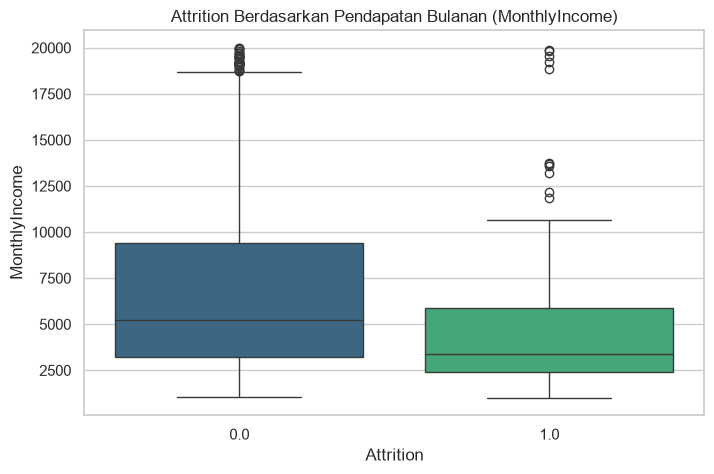

In [10]:
# Kompensasi: Hubungan Attrition dengan MonthlyIncome
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='Attrition', y='MonthlyIncome', palette='viridis')
plt.title('Attrition Berdasarkan Pendapatan Bulanan (MonthlyIncome)')
plt.show()

## batas 


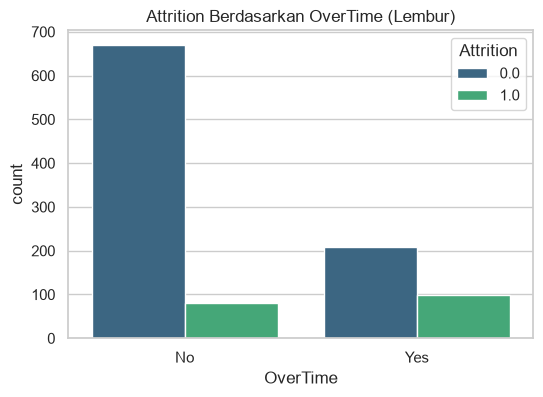

In [31]:
# Hubungan Attrition dengan OverTime
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='OverTime', hue='Attrition', palette='viridis')
plt.title('Attrition Berdasarkan OverTime (Lembur)')
plt.show()


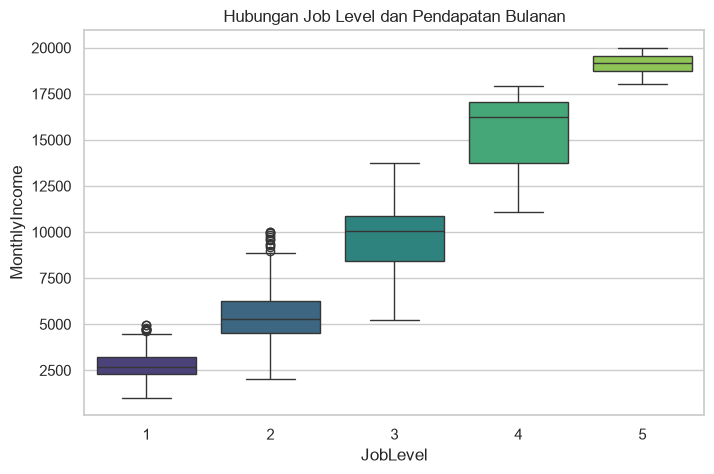

In [33]:
# Job Level vs Monthly Income
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='JobLevel', y='MonthlyIncome', palette='viridis')
plt.title('Hubungan Job Level dan Pendapatan Bulanan')
plt.show()


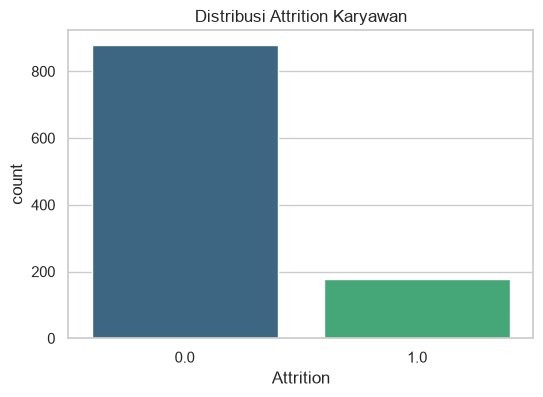

In [16]:
# Setup visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Distribusi Attrition (Target Variable)
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Attrition', palette='viridis')
plt.title('Distribusi Attrition Karyawan')
plt.show()


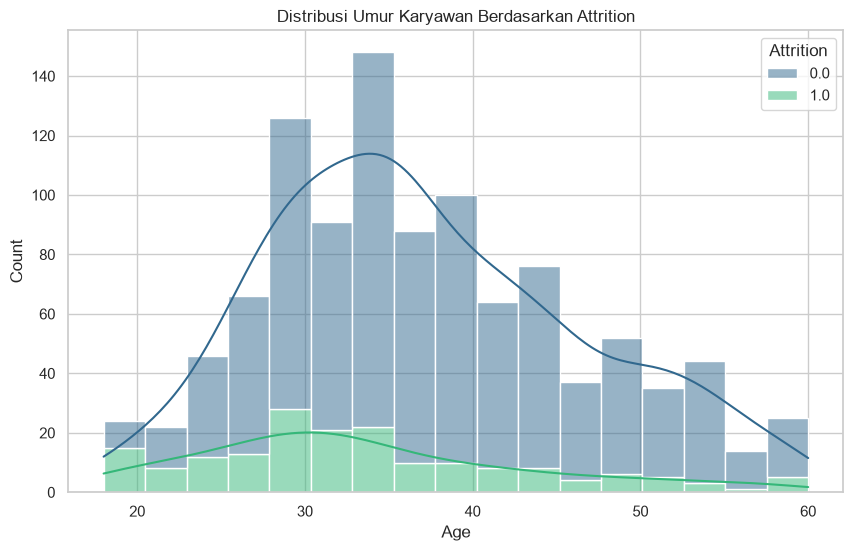

In [17]:
# Distribusi Umur Karyawan berdasarkan Attrition
plt.figure(figsize=(10,6))
sns.histplot(data=data, x='Age', hue='Attrition', kde=True, palette='viridis', multiple="stack")
plt.title('Distribusi Umur Karyawan Berdasarkan Attrition')
plt.show()


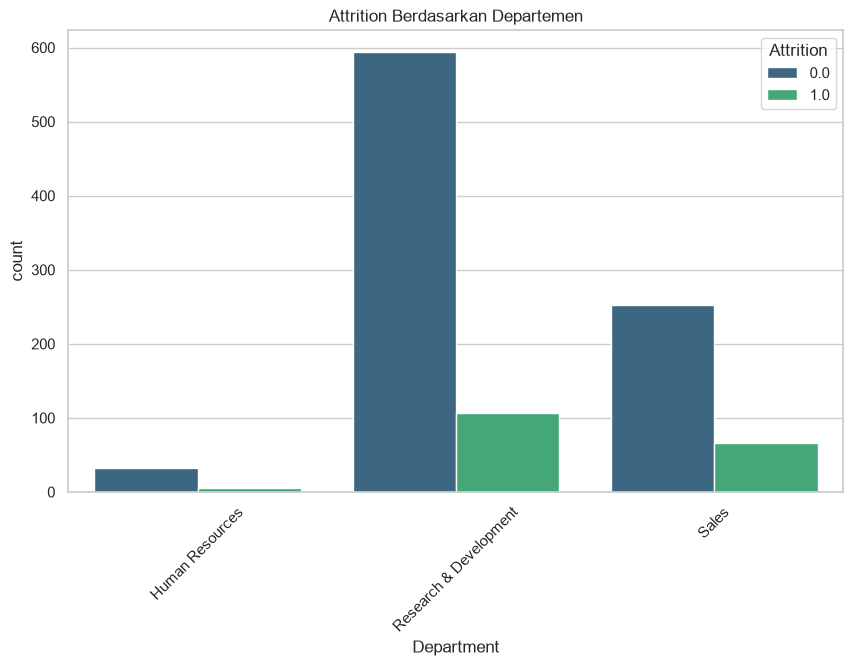

In [18]:
# Hubungan Attrition dengan Department
plt.figure(figsize=(10,6))
sns.countplot(data=data, x='Department', hue='Attrition', palette='viridis')
plt.title('Attrition Berdasarkan Departemen')
plt.xticks(rotation=45)
plt.show()


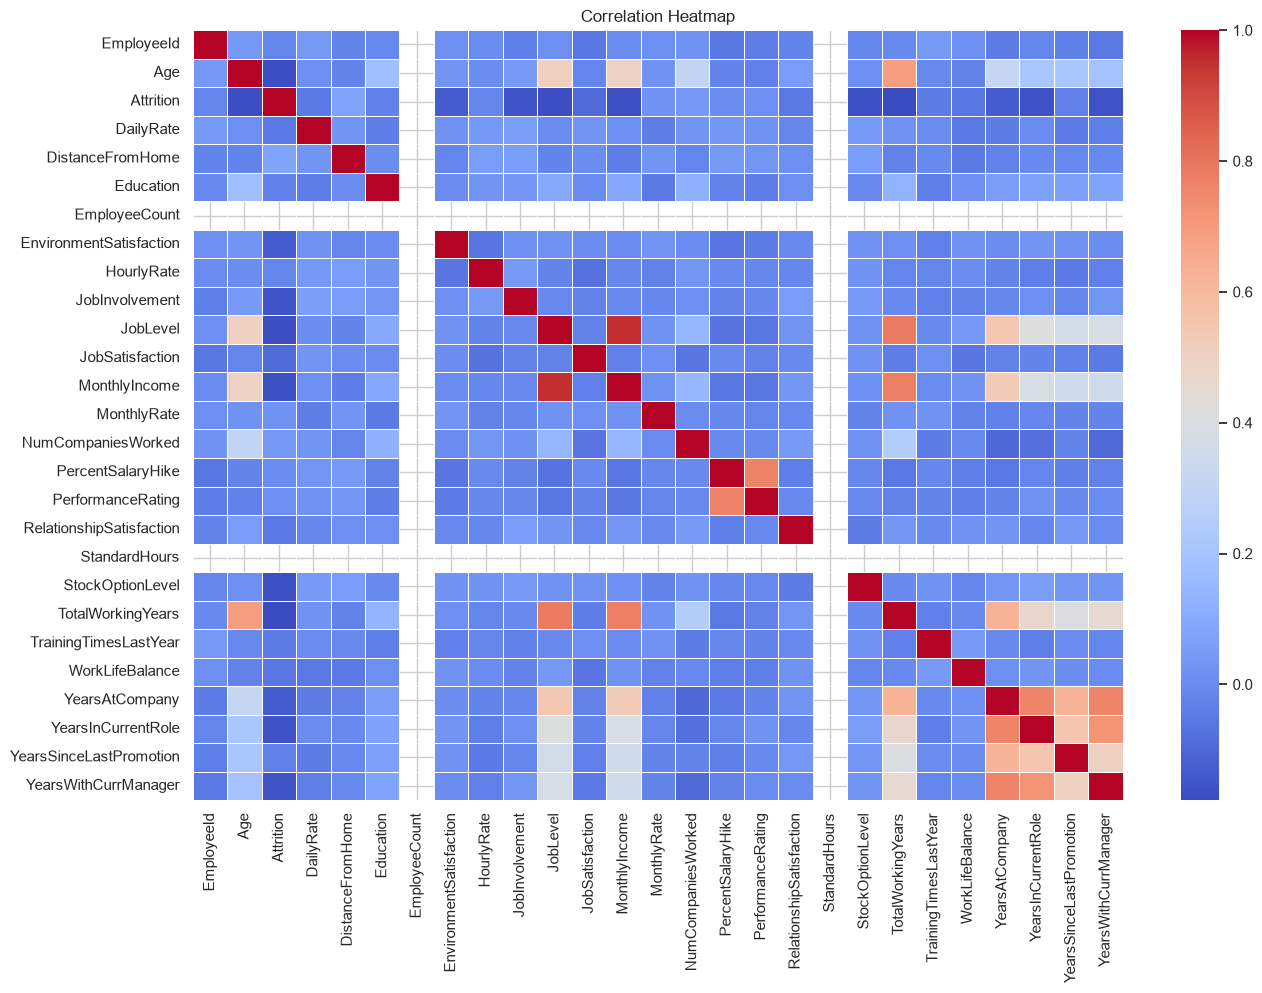

In [23]:
# Correlation Heatmap untuk fitur numerik
numeric_data = data.select_dtypes(include=[np.number])
plt.figure(figsize=(15,10))
sns.heatmap(numeric_data.corr(), cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


**Insight dari Heatmap:**
- **JobLevel ↔ MonthlyIncome** (Korelasi positif sangat kuat): Semakin tinggi level jabatan, gajinya semakin besar.
- **Age ↔ TotalWorkingYears** (Korelasi positif kuat): Karyawan yang lebih tua secara alami memiliki pengalaman kerja yang lebih lama.
- **YearsAtCompany ↔ YearsInCurrentRole / YearsWithCurrManager** (Korelasi positif kuat): Lama bekerja di perusahaan sejalan dengan lamanya di satu peran/manajer.
- **Attrition ↔ Age / MonthlyIncome / TotalWorkingYears** (Korelasi negatif): Karyawan yang lebih tua, bergaji besar, dan lebih berpengalaman, memiliki kemungkinan `resign` yang lebih kecil.



## Modeling

## Evaluation